# Sprawozdanie: Rekurencyjne mnozenie macierzy

## Wstep

Mnozenie macierzy jest jednym z podstawowych zadan obliczen numerycznych.
Dla dwoch macierzy kwadratowych `A` i `B` o wymiarze `n x n` klasyczny
algorytm mnozenia wykonuje rzad `n^3` mnozen i dodawan, a jego zlozonosc
czasowa wynosi `O(n^3)`. W wersji blokowej macierze dzieli sie na cztery
podmacierze i rekurencyjnie laczy wyniki osmiu mnozen blokowych.

Algorytm Strassena zmniejsza liczbe mnozen blokowych z osmiu do siedmiu.
Odbywa sie to kosztem wiekszej liczby dodawan i odejmowan, ale asymptotycznie
daje lepsza zlozonosc `O(n^(log2 7)) ~= O(n^2.81)`. Dla odpowiednio duzych
macierzy moze to prowadzic do przyspieszenia obliczen.

Celem projektu jest implementacja hybrydowego algorytmu rekurencyjnego:

- dla macierzy o rozmiarze `n <= 2^l` stosowany jest algorytm Strassena,
- dla wiekszych macierzy stosowany jest klasyczny algorytm blokowy (Binet),
- dodatkowo liczona jest liczba operacji zmiennoprzecinkowych oraz czas
  wykonania dla roznych wartosci parametru `l`.

## Opis algorytmu

Niech `multiply(A, B, l)` oznacza funkcje obliczajaca iloczyn dwoch macierzy
kwadratowych o rozmiarze bedacym potega dwojki.

1. Jesli `n = 1`, wynik jest rowny `[[A[0][0] * B[0][0]]]`.
2. Jesli `n <= 2^l`, wykonywany jest krok Strassena:
   - macierze sa dzielone na bloki `A11`, `A12`, `A21`, `A22`
     oraz `B11`, `B12`, `B21`, `B22`,
   - liczonych jest siedem iloczynow pomocniczych:

```text
P1 = (A11 + A22)(B11 + B22)
P2 = (A21 + A22)B11
P3 = A11(B12 - B22)
P4 = A22(B21 - B11)
P5 = (A11 + A12)B22
P6 = (A21 - A11)(B11 + B12)
P7 = (A12 - A22)(B21 + B22)
```

   - z iloczynow skladane sa bloki wyniku:

```text
C11 = P1 + P4 - P5 + P7
C12 = P3 + P5
C21 = P2 + P4
C22 = P1 - P2 + P3 + P6
```

3. Jesli `n > 2^l`, wykonywany jest krok klasyczny:

```text
M1 = A11B11   M2 = A12B21
M3 = A11B12   M4 = A12B22
M5 = A21B11   M6 = A22B21
M7 = A21B12   M8 = A22B22

C11 = M1 + M2
C12 = M3 + M4
C21 = M5 + M6
C22 = M7 + M8
```

4. Kazde dodawanie, odejmowanie i mnozenie skalarne zwieksza licznik operacji
   o `1`.

## Implementacja

Implementacja znajduje sie w pliku [binet_strassen.py](/Users/manoftheprincess/Helloworld/Uni/agh/sem1/rachunek macierzowy/program1/binet_strassen.py).
Najwazniejsze elementy programu to:

- klasa `MatrixMultiplier`, ktora przechowuje prog `threshold` oraz licznik
  operacji,
- metody `_add` i `_sub`, realizujace dodawanie i odejmowanie macierzy
  wraz z liczeniem operacji,
- metody `_binet` i `_strassen`, implementujace dwa warianty mnozenia
  rekurencyjnego,
- funkcja `run_experiment`, ktora generuje losowe macierze, uruchamia
  pomiary i zwraca czasy wykonania oraz liczbe operacji,
- funkcja `self_test`, ktora porownuje wyniki algorytmu z referencyjnym
  mnozeniem klasycznym.

Program zaklada, ze macierze sa kwadratowe i maja rozmiar bedacy potega
dwojki. Taka walidacja zostala dodana na wejsciu do funkcji `multiply`,
zeby uniknac blednych danych i ulatwic testowanie.

## Metodologia eksperymentu

Dla wybranych wartosci:

- `k` okreslajacych rozmiar macierzy `n = 2^k`,
- `l` okreslajacych prog `threshold = 2^l`,

generowane sa dwie losowe macierze `A` i `B`, po czym mierzony jest:

- czas wykonania algorytmu,
- laczny licznik operacji zmiennoprzecinkowych.

W notatnikach [code_notebook.ipynb](/Users/manoftheprincess/Helloworld/Uni/agh/sem1/rachunek macierzowy/program1/code_notebook.ipynb)
oraz [report_and_code.ipynb](/Users/manoftheprincess/Helloworld/Uni/agh/sem1/rachunek macierzowy/program1/report_and_code.ipynb)
znajduje sie kod do uruchomienia eksperymentow i narysowania wykresow.

## Oczekiwane obserwacje

Z teorii wynikaja nastepujace wnioski:

- dla malych macierzy przewaga Strassena moze byc niewielka lub zadna,
  poniewaz dodatkowe dodawania i narzut rekurencji sa kosztowne,
- wraz ze wzrostem rozmiaru macierzy liczba mnozen w Strassenie zaczyna
  dawac korzysc asymptotyczna,
- najlepszy prog przelaczania `l` jest zwykle kompromisem miedzy liczba
  operacji a rzeczywistym czasem wykonania.

W praktyce czysty model operacyjny i rzeczywisty czas moga dawac nieco inne
wnioski, poniewaz czas zalezy tez od narzutu interpretera Pythona,
alokacji pamieci i kopiowania podmacierzy.

## Wyniki praktyczne

Na podstawie uruchomionego eksperymentu otrzymano nastepujace wyniki
dla `k = 2, 3, 4, 5, 6` oraz `l = 1, 2, 3`.

### Czas wykonania

| `n = 2^k` | `l = 1` | `l = 2` | `l = 3` |
| --- | ---: | ---: | ---: |
| `4`  | `0.000079 s` | `0.000057 s` | `0.000063 s` |
| `8`  | `0.000527 s` | `0.000401 s` | `0.000373 s` |
| `16` | `0.005330 s` | `0.003192 s` | `0.003085 s` |
| `32` | `0.048467 s` | `0.025833 s` | `0.023831 s` |
| `64` | `0.211794 s` | `0.209029 s` | `0.191168 s` |

### Liczba operacji

| `n = 2^k` | `l = 1` | `l = 2` | `l = 3` |
| --- | ---: | ---: | ---: |
| `4`  | `216` | `247` | `247` |
| `8`  | `1792` | `2040` | `2017` |
| `16` | `14592` | `16576` | `16392` |
| `32` | `117760` | `133632` | `132160` |
| `64` | `946176` | `1073152` | `1061376` |

### Analiza wynikow

Wyniki praktyczne pokazuja, ze dla wszystkich badanych rozmiarow macierzy
najszybszy okazal sie wariant z `l = 3`, czyli z progiem `threshold = 8`.
Roznice sa male dla najmniejszych danych, ale rosna wraz z rozmiarem
problemu. Dla `n = 64` czas spadl z `0.211794 s` dla `l = 1` do
`0.191168 s` dla `l = 3`, czyli o okolo `9.7%`.

Jednoczesnie sama liczba operacji nie wskazuje na ten sam wariant jako
najlepszy. Najmniej operacji odnotowano dla `l = 1`, a mimo to ten wariant
nie byl najszybszy. Oznacza to, ze w implementacji w Pythonie narzut
rekurencji, tworzenia list i kopiowania podmacierzy ma istotny wplyw na
rzeczywisty czas wykonania. Innymi slowy, mniejsza liczba operacji
arytmetycznych nie musi od razu oznaczac krotszego czasu dzialania programu.

W badanym zakresie rozmiarow najlepszy kompromis miedzy liczba operacji a
czasem wykonania daje `l = 3`. Wariant `l = 1` minimalizuje liczbe operacji,
ale przegrywa czasowo. Wariant `l = 2` daje wynik posredni, a `l = 3`
wykorzystuje wieksze podproblemy Strassena na tyle skutecznie, ze przewaza to
nad dodatkowym kosztem organizacji obliczen.

Mozna wiec sformulowac praktyczny wniosek, ze dla tej konkretnej implementacji
i dla badanego zakresu `n` najlepszym wyborem jest prog `2^3 = 8`. Jest to
dobry przyklad tego, ze optymalny parametr hybrydowego algorytmu powinien byc
dobierany eksperymentalnie, a nie tylko na podstawie analizy asymptotycznej.

## Wnioski

Projekt realizuje wszystkie wymagane elementy:

- implementacje rekurencyjnego mnozenia blokowego,
- implementacje algorytmu Strassena,
- hybrydowe przelaczanie z parametrem `l`,
- zliczanie operacji zmiennoprzecinkowych,
- pomiar czasu wykonania,
- analiza wynikow praktycznych dla kilku progow przelaczania,
- kod do eksperymentow i wizualizacji wynikow.

Uzyskany program nadaje sie do porownania zachowania obu algorytmow dla
roznych rozmiarow danych. Dodatkowa walidacja danych oraz test zgodnosci z
algorytmem referencyjnym pomagaja upewnic sie, ze implementacja jest poprawna.


In [1]:
"""
Implementation of recursive matrix multiplication algorithms: classical (Binét) and
Strassen.  The module exposes a `MatrixMultiplier` class that can multiply two
square matrices of size ``n × n`` where ``n`` is a power of two.  The
``MatrixMultiplier`` chooses between Strassen's algorithm and the classical
block multiplication (here referred to as Binét) depending on a user-supplied
threshold size.  When the current matrix size is less than or equal to this
threshold, Strassen's algorithm is applied; otherwise, the classical block
multiplication is used.  Both algorithms are implemented recursively.

In addition to computing the product matrix, the multiplier counts the number
of floating‑point operations (additions/subtractions and multiplications)
performed during the computation.  This allows empirical comparison of the
efficiency of different thresholds.  A convenience function ``run_experiment``
is provided to generate random matrices, run the multiplication for a range
of matrix sizes and thresholds, and collect timing and operation count data.

The code is written using plain Python lists to explicitly account for each
arithmetic operation.  It is not optimized for speed but is suitable for
educational purposes, small problem sizes and to illustrate differences
between algorithms.
"""

from __future__ import annotations

import random
import time
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple


Matrix = List[List[float]]


def _is_power_of_two(n: int) -> bool:
    """Return True when ``n`` is a positive power of two."""
    return n > 0 and (n & (n - 1)) == 0


def _validate_matrix(matrix: Matrix, name: str) -> None:
    """Validate that ``matrix`` is a non-empty square matrix."""
    if not matrix or not matrix[0]:
        raise ValueError(f"{name} must be a non-empty square matrix")

    n = len(matrix)
    if any(len(row) != n for row in matrix):
        raise ValueError(f"{name} must be square (got {n} rows with inconsistent column counts)")

    if not _is_power_of_two(n):
        raise ValueError(f"{name} must have size equal to a power of two (got {n}x{n})")


@dataclass
class MatrixMultiplier:
    """Performs recursive matrix multiplication with operation counting.

    Parameters
    ----------
    threshold : int
        The maximum matrix dimension at which Strassen's algorithm will be
        applied.  When the current subproblem dimension ``n`` is greater than
        ``threshold``, the classical block multiplication (Binét) is used
        instead.  Note that the threshold is an absolute dimension (e.g., 8
        corresponds to matrices up to 8×8).  For matrix sizes ``n <= 1`` the
        direct multiplication is performed without further recursion.
    """
    threshold: int

    def __post_init__(self) -> None:
        self.operations: int = 0

    def reset_operations(self) -> None:
        """Reset the operation counter to zero."""
        self.operations = 0

    # ------------------------------------------------------------------
    # Helpers for matrix operations with operation counting
    def _add(self, A: Matrix, B: Matrix) -> Matrix:
        """Element‑wise addition of two matrices with operation counting."""
        n = len(A)
        C = [[0.0] * n for _ in range(n)]
        for i in range(n):
            rowA = A[i]
            rowB = B[i]
            rowC = C[i]
            for j in range(n):
                # one floating point addition
                rowC[j] = rowA[j] + rowB[j]
                self.operations += 1
        return C

    def _sub(self, A: Matrix, B: Matrix) -> Matrix:
        """Element‑wise subtraction of two matrices with operation counting."""
        n = len(A)
        C = [[0.0] * n for _ in range(n)]
        for i in range(n):
            rowA = A[i]
            rowB = B[i]
            rowC = C[i]
            for j in range(n):
                # one floating point subtraction is counted as an addition
                rowC[j] = rowA[j] - rowB[j]
                self.operations += 1
        return C

    def _combine_quadrants(self, C11: Matrix, C12: Matrix, C21: Matrix, C22: Matrix) -> Matrix:
        """Combine four submatrices into a single matrix."""
        n2 = len(C11)
        n = n2 * 2
        C = [[0.0] * n for _ in range(n)]
        for i in range(n2):
            # copy top rows
            C[i][:n2] = C11[i]
            C[i][n2:] = C12[i]
        for i in range(n2):
            # copy bottom rows
            C[i + n2][:n2] = C21[i]
            C[i + n2][n2:] = C22[i]
        return C

    def _split_quadrants(self, A: Matrix) -> Tuple[Matrix, Matrix, Matrix, Matrix]:
        """Split a square matrix into four equal quadrants."""
        n2 = len(A) // 2
        return (
            [row[:n2] for row in A[:n2]],
            [row[n2:] for row in A[:n2]],
            [row[:n2] for row in A[n2:]],
            [row[n2:] for row in A[n2:]],
        )

    # ------------------------------------------------------------------
    # Core multiplication routine
    def multiply(self, A: Matrix, B: Matrix) -> Matrix:
        """Validate inputs and multiply matrices ``A`` and ``B``."""
        _validate_matrix(A, "A")
        _validate_matrix(B, "B")
        if len(A) != len(B):
            raise ValueError(
                f"A and B must have the same dimensions, got {len(A)}x{len(A)} and {len(B)}x{len(B)}"
            )
        return self._multiply_recursive(A, B)

    def _multiply_recursive(self, A: Matrix, B: Matrix) -> Matrix:
        """Multiply matrices ``A`` and ``B`` using the selected algorithm.

        The algorithm used depends on the current dimension and the ``threshold``
        attribute.  This method updates the ``operations`` counter.
        """
        n = len(A)
        # Base case: 1×1 matrix multiplication
        if n == 1:
            # one multiplication
            self.operations += 1
            return [[A[0][0] * B[0][0]]]

        # Decide algorithm based on threshold
        if n <= self.threshold:
            return self._strassen(A, B)
        else:
            return self._binet(A, B)

    # ------------------------------------------------------------------
    # Classical recursive multiplication (Binét)
    def _binet(self, A: Matrix, B: Matrix) -> Matrix:
        """Classical block multiplication (referred to as Binét)."""
        A11, A12, A21, A22 = self._split_quadrants(A)
        B11, B12, B21, B22 = self._split_quadrants(B)

        # Compute subproducts recursively (8 multiplications)
        M1 = self._multiply_recursive(A11, B11)
        M2 = self._multiply_recursive(A12, B21)
        M3 = self._multiply_recursive(A11, B12)
        M4 = self._multiply_recursive(A12, B22)
        M5 = self._multiply_recursive(A21, B11)
        M6 = self._multiply_recursive(A22, B21)
        M7 = self._multiply_recursive(A21, B12)
        M8 = self._multiply_recursive(A22, B22)

        # Combine results: C11 = M1 + M2; C12 = M3 + M4; C21 = M5 + M6; C22 = M7 + M8
        C11 = self._add(M1, M2)
        C12 = self._add(M3, M4)
        C21 = self._add(M5, M6)
        C22 = self._add(M7, M8)
        return self._combine_quadrants(C11, C12, C21, C22)

    # ------------------------------------------------------------------
    # Strassen's recursive multiplication
    def _strassen(self, A: Matrix, B: Matrix) -> Matrix:
        """Strassen's matrix multiplication algorithm."""
        n = len(A)
        if n == 1:
            return [[A[0][0] * B[0][0]]]

        A11, A12, A21, A22 = self._split_quadrants(A)
        B11, B12, B21, B22 = self._split_quadrants(B)

        # Compute the seven products recursively
        # P1 = (A11 + A22)*(B11 + B22)
        S1 = self._add(A11, A22)
        S2 = self._add(B11, B22)
        P1 = self._multiply_recursive(S1, S2)
        # P2 = (A21 + A22)*B11
        S3 = self._add(A21, A22)
        P2 = self._multiply_recursive(S3, B11)
        # P3 = A11*(B12 - B22)
        S4 = self._sub(B12, B22)
        P3 = self._multiply_recursive(A11, S4)
        # P4 = A22*(B21 - B11)
        S5 = self._sub(B21, B11)
        P4 = self._multiply_recursive(A22, S5)
        # P5 = (A11 + A12)*B22
        S6 = self._add(A11, A12)
        P5 = self._multiply_recursive(S6, B22)
        # P6 = (A21 - A11)*(B11 + B12)
        S7 = self._sub(A21, A11)
        S8 = self._add(B11, B12)
        P6 = self._multiply_recursive(S7, S8)
        # P7 = (A12 - A22)*(B21 + B22)
        S9 = self._sub(A12, A22)
        S10 = self._add(B21, B22)
        P7 = self._multiply_recursive(S9, S10)

        # Compute the four quadrants of C
        # C11 = P1 + P4 - P5 + P7
        C11 = self._add(self._sub(self._add(P1, P4), P5), P7)
        # C12 = P3 + P5
        C12 = self._add(P3, P5)
        # C21 = P2 + P4
        C21 = self._add(P2, P4)
        # C22 = P1 - P2 + P3 + P6
        C22 = self._add(self._add(self._sub(P1, P2), P3), P6)

        return self._combine_quadrants(C11, C12, C21, C22)


def _generate_random_matrix(n: int) -> Matrix:
    """Generate an n×n matrix with random floating‑point entries."""
    return [[random.random() for _ in range(n)] for _ in range(n)]


def classical_reference(A: Matrix, B: Matrix) -> Matrix:
    """Reference triple-loop multiplication used for correctness checks."""
    _validate_matrix(A, "A")
    _validate_matrix(B, "B")
    if len(A) != len(B):
        raise ValueError("A and B must have the same dimensions")

    n = len(A)
    C = [[0.0] * n for _ in range(n)]
    for i in range(n):
        for k in range(n):
            for j in range(n):
                C[i][j] += A[i][k] * B[k][j]
    return C


def matrices_close(A: Matrix, B: Matrix, tol: float = 1e-9) -> bool:
    """Return True when matrices are equal up to ``tol``."""
    if len(A) != len(B):
        return False
    return all(
        abs(A[i][j] - B[i][j]) <= tol
        for i in range(len(A))
        for j in range(len(A))
    )


def run_experiment(
    k_values: List[int],
    l_values: List[int],
    *,
    seed: Optional[int] = None,
) -> Dict[int, Dict[int, Tuple[float, int]]]:
    """Run timing and operation count experiments.

    Parameters
    ----------
    k_values : list of ints
        Exponents defining matrix sizes ``2^k`` to test (e.g. k=2 tests
        4×4 matrices).
    l_values : list of ints
        Threshold exponents ``l``.  For a given ``l``, the threshold
        dimension used in the multiplier is ``2**l``.  For each k and l
        combination the experiment generates two random matrices of size
        ``2**k``, multiplies them using a new ``MatrixMultiplier`` with
        threshold ``2**l``, and records execution time and number of
        floating‑point operations.

    Returns
    -------
    results : dict
        A nested dictionary ``results[l][k] = (elapsed_time, operations)``
        with the measured execution time in seconds and the counted number
        of floating‑point operations for each combination of threshold and
        matrix size.
    """
    if seed is not None:
        random.seed(seed)

    results: Dict[int, Dict[int, Tuple[float, int]]] = {}
    for l in sorted(l_values):
        threshold = 2 ** l
        results[l] = {}
        for k in sorted(k_values):
            n = 2 ** k
            # Generate random matrices
            A = _generate_random_matrix(n)
            B = _generate_random_matrix(n)
            # Create a multiplier with the current threshold
            multiplier = MatrixMultiplier(threshold)
            start = time.perf_counter()
            multiplier.multiply(A, B)
            end = time.perf_counter()
            elapsed = end - start
            results[l][k] = (elapsed, multiplier.operations)

    return results


def self_test() -> None:
    """Run a small deterministic correctness check."""
    test_cases = [
        (
            [[1.0]],
            [[7.0]],
        ),
        (
            [[1.0, 2.0], [3.0, 4.0]],
            [[5.0, 6.0], [7.0, 8.0]],
        ),
        (
            [
                [1.0, 2.0, 3.0, 4.0],
                [5.0, 6.0, 7.0, 8.0],
                [9.0, 10.0, 11.0, 12.0],
                [13.0, 14.0, 15.0, 16.0],
            ],
            [
                [16.0, 15.0, 14.0, 13.0],
                [12.0, 11.0, 10.0, 9.0],
                [8.0, 7.0, 6.0, 5.0],
                [4.0, 3.0, 2.0, 1.0],
            ],
        ),
    ]

    for threshold in (1, 2, 4):
        multiplier = MatrixMultiplier(threshold)
        for A, B in test_cases:
            product = multiplier.multiply(A, B)
            reference = classical_reference(A, B)
            if not matrices_close(product, reference):
                raise AssertionError(
                    f"Incorrect result for threshold={threshold}: {product!r} != {reference!r}"
                )
            multiplier.reset_operations()


if __name__ == "__main__":
    self_test()

    # Example usage for quick manual testing. Runs a small experiment
    # after a correctness check and prints the collected measurements.
    ks = [2, 3]
    ls = [1, 2]
    res = run_experiment(ks, ls, seed=42)
    for l, rdict in res.items():
        print(f"Threshold 2^{l} (n={2**l})")
        for k, (t, ops) in rdict.items():
            print(f"  n=2^{k} -> time {t:.6f}s, ops {ops}")


Threshold 2^1 (n=2)
  n=2^2 -> time 0.000054s, ops 216
  n=2^3 -> time 0.000488s, ops 1792
Threshold 2^2 (n=4)
  n=2^2 -> time 0.000061s, ops 247
  n=2^3 -> time 0.000463s, ops 2040


Threshold 2^1 (n=2)
  n=2^2 -> time 0.000079s, ops 216
  n=2^3 -> time 0.000527s, ops 1792
  n=2^4 -> time 0.005330s, ops 14592
  n=2^5 -> time 0.048467s, ops 117760
  n=2^6 -> time 0.211794s, ops 946176
Threshold 2^2 (n=4)
  n=2^2 -> time 0.000057s, ops 247
  n=2^3 -> time 0.000401s, ops 2040
  n=2^4 -> time 0.003192s, ops 16576
  n=2^5 -> time 0.025833s, ops 133632
  n=2^6 -> time 0.209029s, ops 1073152
Threshold 2^3 (n=8)
  n=2^2 -> time 0.000063s, ops 247
  n=2^3 -> time 0.000373s, ops 2017
  n=2^4 -> time 0.003085s, ops 16392
  n=2^5 -> time 0.023831s, ops 132160
  n=2^6 -> time 0.191168s, ops 1061376


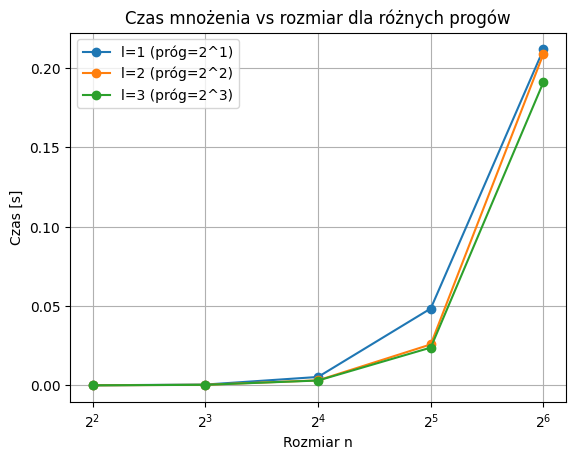

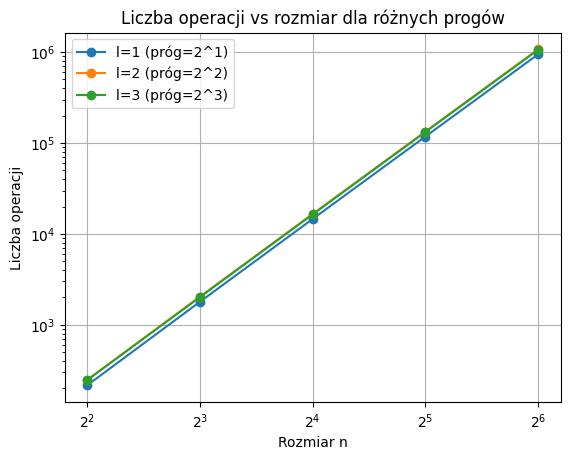

In [2]:

# Parametry eksperymentu
ks = [2,3,4,5,6]  # rozmiary macierzy n = 2**k
ls = [1,2,3]      # progi l (threshold = 2**l)

# Uruchom eksperyment
data = run_experiment(ks, ls)

# Wyświetl wyniki
for l, d in data.items():
    print(f'Threshold 2^{l} (n={2**l})')
    for k, (t, ops) in d.items():
        print(f'  n=2^{k} -> time {t:.6f}s, ops {ops}')

# Wykresy
import matplotlib.pyplot as plt
sizes = [2**k for k in ks]
# Wykres czasu
for l in ls:
    times = [data[l][k][0] for k in ks]
    plt.plot(sizes, times, marker='o', label=f'l={l} (próg=2^{l})')
plt.xlabel('Rozmiar n')
plt.ylabel('Czas [s]')
plt.title('Czas mnożenia vs rozmiar dla różnych progów')
plt.legend()
plt.grid(True)
plt.xscale('log', base=2)
plt.show()
# Wykres operacji
for l in ls:
    ops = [data[l][k][1] for k in ks]
    plt.plot(sizes, ops, marker='o', label=f'l={l} (próg=2^{l})')
plt.xlabel('Rozmiar n')
plt.ylabel('Liczba operacji')
plt.title('Liczba operacji vs rozmiar dla różnych progów')
plt.legend()
plt.grid(True)
plt.xscale('log', base=2)
plt.yscale('log')
plt.show()
